In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import kktk

from tqdm import tqdm

import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

/rfs/project/rfs-iCNyzSAaucw/kk837/github/kktk/kktk/plotting.py:34: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [2]:
import session_info
session_info.show()

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  mod_version = _find_version(mod.__version__)
/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [3]:
sc.settings.set_figure_params(dpi=80)

# Function

# Variables

In [4]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
adata_path = f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad'
celltype_key = 'fine_grain_2Feb2026'

In [5]:
!ls {data_object_dir}/TACCO

all_b2c_cells_filtered_celltype-sel_post-tacco_raw.h5ad
coarse_grain_subsets
reference_raw.h5ad
tacco-splitted_ref-HD_raw.h5ad
tacco-splitted_ref-HD-SCN_filtered_raw.h5ad
tacco-splitted_ref-HD-SCN_filtered_rm-unclassified_raw.h5ad
tacco-splitted_ref-HD-SCN_raw.h5ad


In [6]:
!ls {data_object_dir}

all_b2c_cells_filtered_celltype-sel_raw.h5ad
all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad
all_b2c_cells_filtered_niche-sel_raw.h5ad
all_b2c_cells_filtered_raw.h5ad
all_b2c_cells_raw.h5ad
archive_17Nov2025
cellcharter_autok
cellcharter_cluster_subsets
cellphonedb
epicardium-mixture_b2c_cells_filtered_raw.h5ad
erythrocytes_b2c_cells_filtered_raw.h5ad
scVI
sd_hd_pseudobulk_section-donor-niche_sum.h5ad
TACCO
unclassified-mixture_b2c_cells_filtered_raw.h5ad


In [7]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'

# Read in data

In [8]:
# read in
adata = sc.read_h5ad(adata_path)
print(adata.X.data[:5])
adata

[1. 2. 2. 1. 1.]


AnnData object with n_obs × n_vars = 189948 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'fine_grain_2Feb2026'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_pre_colors', 'donor_colors', 'library_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'spatial', 'spati

In [17]:
# add short version of the cell type labels
adata.obs[celltype_key] = adata.obs[celltype_key].astype('str').copy()
df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/finegrain_name_mapping.csv')
celltype_mapping = df.set_index('Full_name')['Short_name_finalised'].to_dict()
adata.obs.replace({celltype_key:celltype_mapping},inplace=True)
set(adata.obs[celltype_key])

{'AVNPC',
 'ArtEC',
 'CorCapEC',
 'CorMural',
 'DASMC',
 'EPDC',
 'Endocard',
 'FB',
 'FBCOL2A1',
 'FBPITX2',
 'GVSMC',
 'ILC',
 'LymphEC',
 'MPLYVE1',
 'MacCX3',
 'MesEpiC',
 'Mono',
 'NK',
 'ParaN',
 'SANPCHd',
 'SANPCTl',
 'SHPC',
 'SchwC',
 'SympN',
 'VCSDist',
 'VCSProx',
 'ValveEC',
 'ValveIC',
 'VenEC',
 'aCML',
 'aCMNeur',
 'aCMR',
 'aCMTrans',
 'vCMC',
 'vCMT'}

# Add SAN axis

In [9]:
adata_sanpc = sc.read_h5ad(f'{data_object_dir}/TACCO/coarse_grain_subsets/b2c_cells_SinoatrialNodePacemakerCells_lognorm.h5ad',
                               backed='r')
print(adata_sanpc.shape)

(3380, 17854)


In [10]:
axis_name = 'SAN_axis'
adata.obs[axis_name] = adata_sanpc.obs[axis_name].reindex(adata.obs_names).copy()
adata.obs[f'{axis_name}_bin_annot'] = adata_sanpc.obs[f'{axis_name}_bin_annot'].reindex(adata.obs_names).copy()

In [11]:
(adata.obs[axis_name].isna()==False).sum()

np.int64(3380)

# Spatial clustering and obtain neighbouring information

In [14]:
import squidpy as sq
from tqdm import tqdm
import anndata

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [18]:
%%time
# constructing spatial neighborhood graph
sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=20, 
                        spatial_key="spatial", library_key='section_ID')
spatial_connect = adata.obsp['spatial_connectivities'].copy()

# mask for pacemaker cells
mask = np.array(adata.obs[axis_name].isna()==False)
print(spatial_connect[:,mask].shape)

# Step 1: Transpose the sparse matrix
sparse_matrix_T = spatial_connect[:,mask].T  
# Step 2: Initialize a dictionary to store neighbor cell type counts for each pseudotime cell
neighbor_cell_types = {i: [] for i in range(sparse_matrix_T.shape[0])}
# Step 3: Identify neighbors for each pseudotime cell and aggregate cell types
cell_types = list(adata.obs[celltype_key])
for i in tqdm(range(sparse_matrix_T.shape[0])):
    neighbors = np.nonzero(sparse_matrix_T[i])[1]  # Get indices of neighbors
    neighbor_types = [cell_types[j] for j in neighbors]
    neighbor_cell_types[i].extend(neighbor_types)
# Step 4: Convert to DataFrame for easier analysis
neighbor_df = pd.DataFrame.from_dict(neighbor_cell_types, orient='index')
# Calculate frequency or proportion of each cell type for each pseudotime
cell_type_counts = neighbor_df.apply(pd.Series.value_counts, axis=1).fillna(0)
# add pseudotime
cell_type_counts.index = adata.obs_names[mask]

(189948, 3380)


100%|██████████| 3380/3380 [00:02<00:00, 1292.90it/s]


CPU times: user 4.78 s, sys: 71.2 ms, total: 4.85 s
Wall time: 4.83 s


In [19]:
cell_type_counts

,AVNPC,ArtEC,CorCapEC,CorMural,DASMC,EPDC,Endocard,FB,GVSMC,ILC,...,VCSProx,ValveEC,ValveIC,VenEC,aCML,aCMNeur,aCMR,aCMTrans,vCMC,vCMT
HEA_FOET14880396___29380,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HEA_FOET14880396___29382,0.0,0.0,3.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HEA_FOET14880396___29384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,2.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
HEA_FOET14880396___29385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HEA_FOET14880396___29389,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CellTalkHHD_Human_13_BRC2757-2758-7___212301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CellTalkHHD_Human_13_BRC2757-2758-7___213048,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
CellTalkHHD_Human_13_BRC2757-2758-7___213149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
CellTalkHHD_Human_13_BRC2757-2758-7___218649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
cell_type_counts[f'{axis_name}_bin_annot']=adata.obs.loc[cell_type_counts.index,f'{axis_name}_bin_annot']
axis_neighbours_df = cell_type_counts.groupby(f'{axis_name}_bin_annot').mean()
axis_neighbours_df = axis_neighbours_df.dropna()
axis_neighbours_df.max().sort_values(ascending=False)

/tmp/ipykernel_2103690/3570199239.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  axis_neighbours_df = cell_type_counts.groupby(f'{axis_name}_bin_annot').mean()


SANPCHd     18.928793
SANPCTl     12.547124
SHPC        10.071533
aCMR         4.138311
AVNPC        3.188153
FB           3.046715
VenEC        0.889051
aCMTrans     0.778102
MesEpiC      0.764964
LymphEC      0.418978
vCMC         0.395620
aCML         0.280294
VCSProx      0.267806
ParaN        0.247863
CorMural     0.242775
CorCapEC     0.138728
ValveIC      0.135766
aCMNeur      0.117503
EPDC         0.104046
ILC          0.091168
MPLYVE1      0.065693
ArtEC        0.051095
vCMT         0.045255
MacCX3       0.042857
ValveEC      0.041812
Mono         0.035714
GVSMC        0.033577
Endocard     0.030600
NK           0.020438
DASMC        0.013139
SchwC        0.011679
dtype: float64

--> ventricular cardiomyocytes being here is likely to be because of capturing beyond tissue edge (see the plot of SANaxis in sections in the notebook no2)

In [21]:
# thresholding
mean_thresh = 0.03
axis_neighbours_df = axis_neighbours_df[axis_neighbours_df.columns[axis_neighbours_df.max()>mean_thresh]].T
axis_neighbours_df.columns

CategoricalIndex(['SinusHorn_1', 'SinusHorn_2', 'SAN_head_1', 'SAN_head_2',
                  'SAN_head_3', 'SAN_head_4', 'SAN_head_5', 'SAN_tail_1',
                  'SAN_tail_2', 'SAN_tail_3'],
                 categories=['SinusHorn_1', 'SinusHorn_2', 'SAN_head_1', 'SAN_head_2', ..., 'SAN_head_5', 'SAN_tail_1', 'SAN_tail_2', 'SAN_tail_3'], ordered=False, dtype='category', name='SAN_axis_bin_annot')

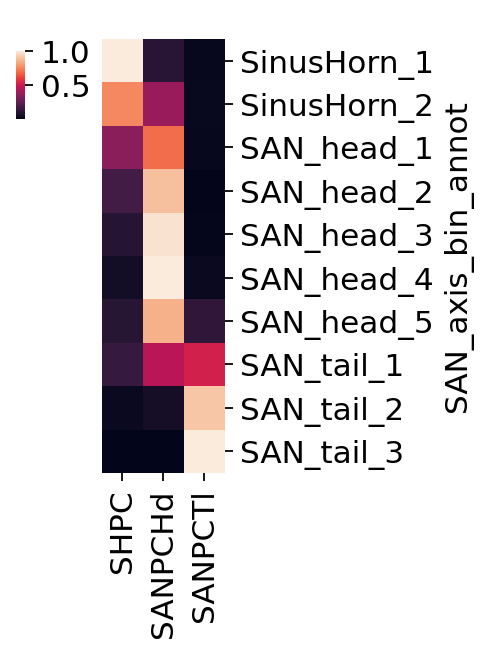

In [46]:
# SAN pacemaker cells
cm_cells = ['SHPC','SANPCHd','SANPCTl']
df = axis_neighbours_df.loc[cm_cells].copy()
# normalise with max value
max_arr = df.max(axis=1)
for col in df.columns:
    df[col] = df[col]/max_arr

# remove "unclassified"
df = df[df.index!='unassigned']

# plotting
plt.rcParams['axes.grid'] = False
sns.clustermap(df.T,
               col_cluster=False,row_cluster=False,figsize=(2.8,4.3),
               dendrogram_ratio=0.05,cbar_pos=(-0.1, 0.8, 0.02, 0.1))
plt.savefig(f'{figdir}/VisiumHD_SANaxis_neighbour-celltypes_PCs.pdf', bbox_inches="tight",dpi=300)
plt.show()

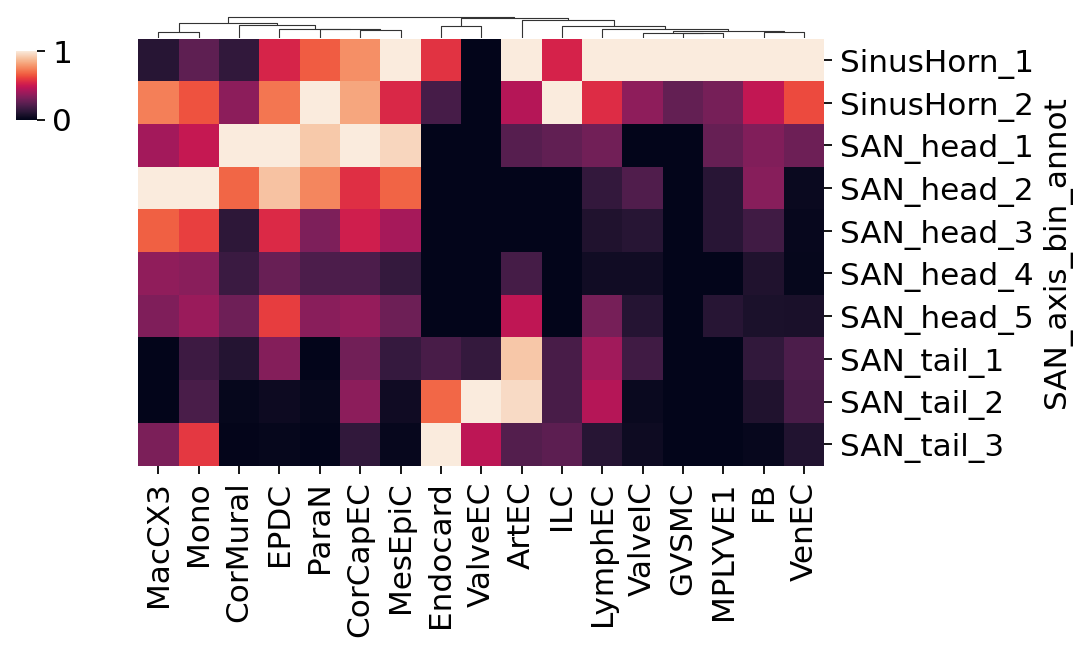

In [55]:
# non-cardiomyocytes
noncm_cells = [
 'ArtEC',
 'CorCapEC',
 'CorMural',
 'DASMC',
 'EPDC',
 'Endocard',
 'FB',
 'FBCOL2A1',
 'FBPITX2',
 'GVSMC',
 'ILC',
 'LymphEC',
 'MPLYVE1',
 'MacCX3',
 'MesEpiC',
 'Mono',
 'NK',
 'ParaN',
 'SchwC',
 'SympN',
 'ValveEC',
 'ValveIC',
 'VenEC',
]

noncm_cells = [x for x in noncm_cells if x in axis_neighbours_df.index]
df = axis_neighbours_df.loc[noncm_cells].copy()
# normalise with max value
max_arr = df.max(axis=1)
for col in df.columns:
    df[col] = df[col]/max_arr

# remove "unclassified"
df = df[df.index!='unassigned']

# plotting
plt.rcParams['axes.grid'] = False
sns.clustermap(df.T,
               row_cluster=False,figsize=(6.5,4.3),
               dendrogram_ratio=0.05,cbar_pos=(-0.05, 0.8, 0.02, 0.1))
plt.savefig(f'{figdir}/VisiumHD_SANaxis_neighbour-celltypes_non-CMs.pdf', bbox_inches="tight",dpi=300)
plt.show()